# KNN
## Preparación del dataset para futuros cálculos

instalación de dependencias

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


Cargamos el dataset y hacemos limpieza básica para dejarlo listo para calcular.

In [2]:
df = pd.read_csv('dataset.csv')

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Selección de columnas numéricas y categóricas útiles para cálculos/KNN
df_model = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
df_model = pd.get_dummies(df_model, columns=['Sex', 'Embarked'], drop_first=True)

Numerizamos parámetros, tratamos las cabinas nulas como desconocido, creamos variables útiles y normalizamos los datos.

In [3]:

# nulos -> desconocido
df['Cabin'] = df['Cabin'].fillna('desconocido')

# deck usada
df['CabinDeck'] = df['Cabin'].astype(str).str[0]
df.loc[df['Cabin'] == 'desconocido', 'CabinDeck'] = 'desconocido'

# Reconstrucción del modelo incluyendo CabinDeck
df_model = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
df_model = pd.get_dummies(df_model, columns=['Sex', 'Embarked', 'CabinDeck'], drop_first=True)

y = df_model['Survived']
X = df_model.drop(columns=['Survived'])

scaler = StandardScaler()
columnas_numericas = X.select_dtypes(include=['int64', 'float64']).columns
X[columnas_numericas] = scaler.fit_transform(X[columnas_numericas])

# Comprobación rápida
display(df[['Cabin', 'CabinDeck']].head())
display(X.head())

,Cabin,CabinDeck
0,desconocido,desconocido
1,C85,C
2,desconocido,desconocido
3,C123,C
4,desconocido,desconocido


,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_desconocido
0,0.825209,-0.563674,0.431350,-0.474326,-0.500240,0.057853,-1.229349,True,False,True,False,False,False,False,False,False,False,True
1,-1.572211,0.669217,0.431350,-0.474326,0.788947,0.057853,-1.229349,False,False,False,False,True,False,False,False,False,False,False
2,0.825209,-0.255451,-0.475199,-0.474326,-0.486650,-0.561804,0.813439,False,False,True,False,False,False,False,False,False,False,True
3,-1.572211,0.438050,0.431350,-0.474326,0.422861,0.057853,-1.229349,False,False,True,False,True,False,False,False,False,False,False
4,0.825209,0.438050,-0.475199,-0.474326,-0.484133,-0.561804,0.813439,True,False,True,False,False,False,False,False,False,False,True


En el siguiente bloque exploramos varias variables para entender mejor qué factores influyen en la supervivencia.

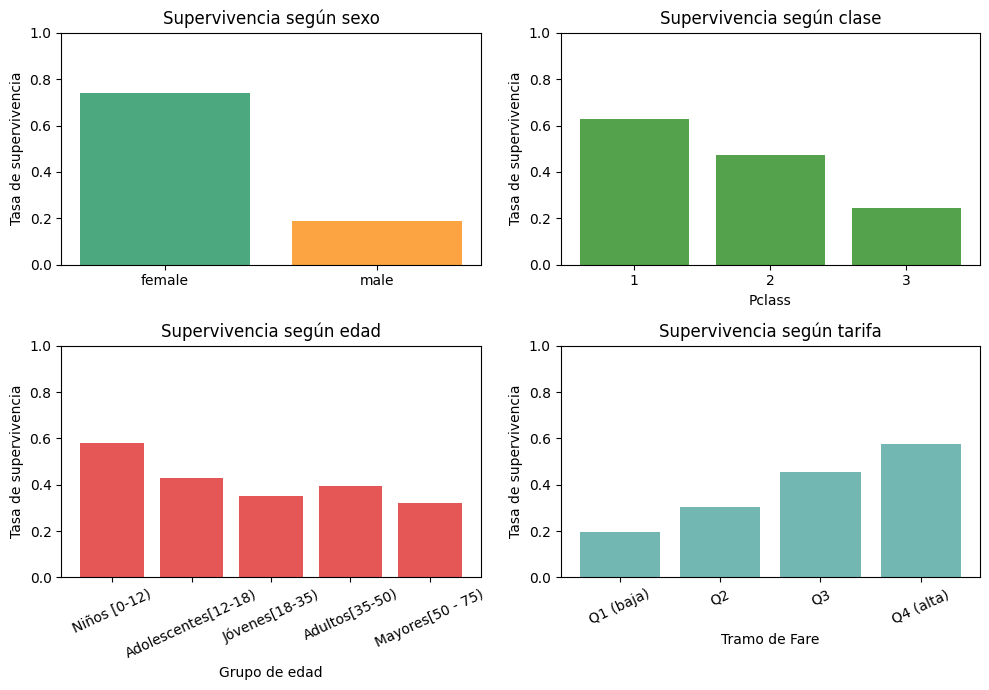

In [4]:
explore_df = df.copy()
explore_df['AgeGroup'] = pd.cut(
    explore_df['Age'],
    bins=[0, 12, 18, 35, 50, 75],
    labels=['Niños [0-12)', 'Adolescentes[12-18)', 'Jóvenes[18-35)', 'Adultos[35-50)', 'Mayores[50 - 75)']
)

explore_df['FareGroup'] = pd.qcut(
    explore_df['Fare'],
    q=4,
    labels=['Q1 (baja)', 'Q2', 'Q3', 'Q4 (alta)'],
    duplicates='drop'
)

sex_survival = explore_df.groupby('Sex')['Survived'].mean().sort_values(ascending=False)
pclass_survival = explore_df.groupby('Pclass')['Survived'].mean().sort_index()
age_survival = explore_df.groupby('AgeGroup', observed=False)['Survived'].mean()
fare_survival = explore_df.groupby('FareGroup', observed=False)['Survived'].mean()

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].bar(sex_survival.index, sex_survival.values, color=["#4CA87F", "#FBA441"])
axes[0, 0].set_title('Supervivencia según sexo')
axes[0, 0].set_ylabel('Tasa de supervivencia')
axes[0, 0].set_ylim(0, 1)

axes[0, 1].bar(pclass_survival.index.astype(str), pclass_survival.values, color='#54A24B')
axes[0, 1].set_title('Supervivencia según clase')
axes[0, 1].set_xlabel('Pclass')
axes[0, 1].set_ylabel('Tasa de supervivencia')
axes[0, 1].set_ylim(0, 1)

axes[1, 0].bar(age_survival.index.astype(str), age_survival.values, color='#E45756')
axes[1, 0].set_title('Supervivencia según edad')
axes[1, 0].set_xlabel('Grupo de edad')
axes[1, 0].set_ylabel('Tasa de supervivencia')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(axis='x', rotation=25)

axes[1, 1].bar(fare_survival.index.astype(str), fare_survival.values, color='#72B7B2')
axes[1, 1].set_title('Supervivencia según tarifa')
axes[1, 1].set_xlabel('Tramo de Fare')
axes[1, 1].set_ylabel('Tasa de supervivencia')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()


En el siguiente bloque entrenamos el KNN.

In [5]:

# División de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Modelo KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predicción y evaluación
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
matriz_confusion = confusion_matrix(y_test, y_pred)
reporte = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print('Matriz de confusión:')
print(matriz_confusion)
print('Reporte de clasificación:')
print(reporte)

Accuracy: 0.7809
Matriz de confusión:
[[92 18]
 [21 47]]
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       110
           1       0.72      0.69      0.71        68

    accuracy                           0.78       178
   macro avg       0.77      0.76      0.77       178
weighted avg       0.78      0.78      0.78       178



graficamos